In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


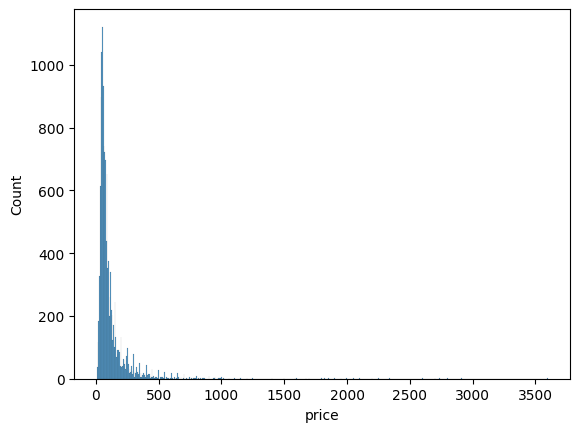

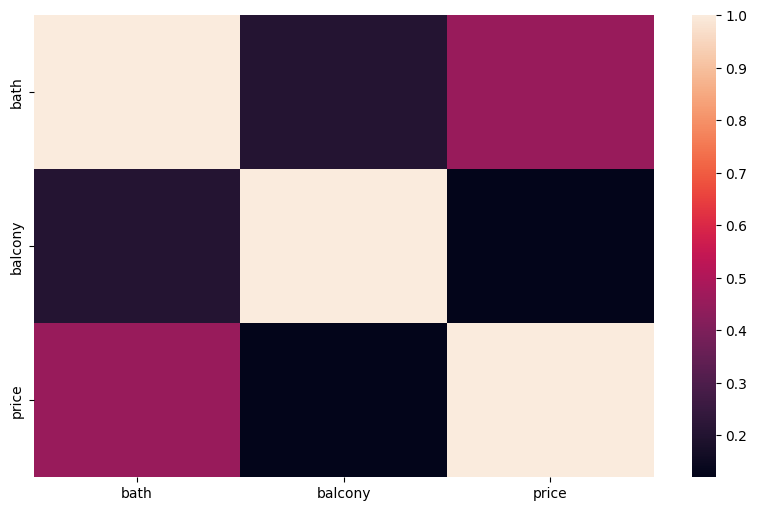

In [3]:
df.info()
df.describe()
df.isnull().sum()

sns.histplot(df["price"])
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=False)
plt.show()


In [4]:
X = df.drop("price", axis=1)
y = df["price"]

In [5]:
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns


In [6]:
from sklearn.impute import SimpleImputer

preprocess = ColumnTransformer([
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),

    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])


In [7]:
model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['bath', 'balcony'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [8]:
pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))


MAE: 41.596337396927744
RMSE: 105.77019839449233
R²: 0.4745395907256733


In [9]:
import joblib
joblib.dump(model, "house_price_model.pkl")


['house_price_model.pkl']

In [10]:
!pip install pyngrok

In [11]:
%%writefile app.py
from flask import Flask, render_template, request
import joblib
import numpy as np

app = Flask(__name__)
model = joblib.load("house_price_model.pkl")

@app.route("/")
def home():
    return render_template("index.html")

@app.route("/predict", methods=["POST"])
def predict():
    # Get input values from form
    data = []
    for x in request.form.values():
        data.append(x)

    # Convert to numpy array
    final_features = np.array([data], dtype=float)

    # Predict
    output = model.predict(final_features)[0]

    return render_template("index.html", prediction_text=f"Predicted Price: ₹{output:,.2f}")

if __name__ == "__main__":
    app.run(host='127.0.0.1', port=5000)


Overwriting app.py


In [12]:
!mkdir -p templates

In [13]:
%%writefile templates/index.html
<!DOCTYPE html>
<html>
<head>
    <title>House Price Prediction</title>
</head>
<body>
    <h2>Enter House Details</h2>

    <form action="/predict" method="post">
        <label>Area (sqft):</label>
        <input type="text" name="area"><br><br>

        <label>BHK:</label>
        <input type="text" name="bhk"><br><br>

        <label>Bathrooms:</label>
        <input type="text" name="bath"><br><br>

        <button type="submit">Predict Price</button>
    </form>

    <h3>{{ prediction_text }}</h3>
</body>
</html>


Overwriting templates/index.html


In [14]:
!nohup python app.py &
!pip install flask-ngrok


nohup: appending output to 'nohup.out'


In [15]:
import pandas as pd
import numpy as np
import threading
from flask import Flask, request, render_template_string
from pyngrok import ngrok
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

# ==========================================
# PART 1: LOAD DATA & TRAIN MODEL
# ==========================================
print("⏳ Phase 1: Training the Model...")

# 1. Load the dataset
try:
    df = pd.read_csv('Bengaluru_House_Data.csv')
except FileNotFoundError:
    print("❌ Error: CSV file not found. Please upload 'Bengaluru_House_Data - Copy.csv'")
    raise

# 2. Clean the Data
# Fix 'total_sqft' ranges (e.g., '1133 - 1384')
def convert_sqft_to_num(x):
    try:
        tokens = str(x).split('-')
        if len(tokens) == 2:
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

# Fix 'size' to get BHK
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]) if isinstance(x, str) else None)

# Fix 'location'
df['location'] = df['location'].apply(lambda x: x.strip() if isinstance(x, str) else 'other')
location_stats = df.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats_less_than_10 = location_stats[location_stats <= 10]
df['location'] = df['location'].apply(lambda x: 'other' if x in location_stats_less_than_10 else x)

# Drop errors
df = df.dropna(subset=['total_sqft', 'bhk', 'bath', 'location'])

# 3. Create Pipeline (The "Brain")
X = df[['location', 'total_sqft', 'bhk', 'bath']]
y = df['price']

# Tells the model: "Please handle the text in 'location' column automatically"
column_trans = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['location']),
    remainder='passthrough'
)

pipe = make_pipeline(column_trans, LinearRegression())
pipe.fit(X, y)

# Get list of locations for the dropdown
locations = sorted(df['location'].unique().tolist())

print("✅ Model Trained Successfully!")

# ==========================================
# PART 2: THE WEBSITE (Flask)
# ==========================================
print("⏳ Phase 2: Starting Website...")

# Kill old servers
!fuser -k 5000/tcp

# Start Ngrok
public_url = ngrok.connect(5000).public_url
print(f" * Public URL: {public_url}")

app = Flask(__name__)

html_code = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Bengaluru House Price Predictor</title>
    <style>
        body { font-family: 'Segoe UI', sans-serif; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); min-height: 100vh; display: flex; align-items: center; justify-content: center; margin: 0; }
        .container { background: rgba(255, 255, 255, 0.95); padding: 2rem; border-radius: 15px; box-shadow: 0 10px 25px rgba(0,0,0,0.2); width: 100%; max-width: 420px; }
        h2 { text-align: center; color: #333; margin-bottom: 1.5rem; }
        label { font-weight: 600; color: #555; display: block; margin-bottom: 0.5rem; margin-top: 1rem; }
        select, input { width: 100%; padding: 12px; border: 1px solid #ccc; border-radius: 8px; font-size: 1rem; box-sizing: border-box; }
        button { width: 100%; padding: 14px; background-color: #764ba2; color: white; border: none; border-radius: 8px; font-size: 1.1rem; font-weight: bold; margin-top: 1.5rem; cursor: pointer; transition: transform 0.1s; }
        button:hover { background-color: #5a387e; transform: scale(1.02); }
        .prediction-box { margin-top: 1.5rem; padding: 1rem; background-color: #d4edda; color: #155724; border: 1px solid #c3e6cb; border-radius: 8px; text-align: center; font-size: 1.2rem; font-weight: bold; }
        .error-box { margin-top: 1.5rem; padding: 1rem; background-color: #f8d7da; color: #721c24; border-radius: 8px; text-align: center; }
    </style>
</head>
<body>
    <div class="container">
        <h2>🏠 Bengaluru House Price</h2>

        <form action="/predict" method="post">
            <label>📍 Location</label>
            <select name="location" required>
                <option value="" disabled selected>Select a location</option>
                {% for loc in locations %}
                    <option value="{{ loc }}">{{ loc }}</option>
                {% endfor %}
            </select>

            <label>📏 Total Square Feet</label>
            <input type="number" step="any" name="sqft" placeholder="e.g. 1500" required>

            <label>🛏️ BHK (Bedrooms)</label>
            <input type="number" name="bhk" placeholder="e.g. 2" required>

            <label>🚿 Bathrooms</label>
            <input type="number" step="0.5" name="bath" placeholder="e.g. 2" required>

            <button type="submit">Predict Price</button>
        </form>

        {% if prediction %}
            <div class="prediction-box">{{ prediction }}</div>
        {% endif %}

        {% if error %}
            <div class="error-box">{{ error }}</div>
        {% endif %}
    </div>
</body>
</html>
"""

@app.route('/')
def home():
    # Pass locations to the template
    return render_template_string(html_code, locations=locations)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # 1. Get Inputs
        loc = request.form['location']
        sqft = float(request.form['sqft'])
        bhk = int(request.form['bhk'])
        bath = float(request.form['bath'])

        # 2. Prepare DataFrame
        input_data = pd.DataFrame([[loc, sqft, bhk, bath]],
                                  columns=['location', 'total_sqft', 'bhk', 'bath'])

        # 3. Predict
        prediction_value = pipe.predict(input_data)[0]

        result = f"Estimated Price: ₹ {prediction_value:.2f} Lakhs"
        return render_template_string(html_code, locations=locations, prediction=result)

    except Exception as e:
        return render_template_string(html_code, locations=locations, error=f"Error: {str(e)}")

# Run the App
threading.Thread(target=app.run, kwargs={"port": 5000}).start()

⏳ Phase 1: Training the Model...
✅ Model Trained Successfully!
⏳ Phase 2: Starting Website...
5000/tcp:            14479
 * Public URL: https://petrographically-nonrhymed-rayna.ngrok-free.dev
 * Serving Flask app '__main__'
